# Multi-Agent Coordination using Tabular Q-Learning
## Objective
Train two independent Q‑Learning agents (Type A and Type B) to operate in the same 5×5 grid world.

Type A: Starts at X (west), travels to U (east) to pick a sample, and returns to X.

Type B: Starts at Y (north), travels to V (south) to pick a sample, and returns to Y.

The central lake (2,2) randomly floods or dries each step.

Type A receives a heavy penalty for entering the lake while flooded.

Type B is waterproof and receives no water penalty.

Collisions are penalized only when both agents are in the lake simultaneously.

Both agents must learn to cross the lake at different times to avoid collisions

In [21]:
import random
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output

# Ensure plots appear inline in Jupyter
print("Libraries loaded successfully.")

Libraries loaded successfully.


## Constants & Hyperparameters
GRID_SIZE = 5

Fixed landmarks: X, Y, U, V, and the LAKE.

Actions: UP, DOWN, LEFT, RIGHT, WAIT.

Lake flip probability: 0.2.

Q‑learning: α = 0.1, γ = 0.95, ε decays from 1.0 to 0.01.

In [22]:
# Grid
GRID_SIZE = 5

# Fixed Locations
X_ROW, X_COL = 2, 0   # Type A start / home
Y_ROW, Y_COL = 0, 2   # Type B start / home
U_ROW, U_COL = 2, 4   # Type A sampling site
V_ROW, V_COL = 4, 2   # Type B sampling site
LAKE_ROW, LAKE_COL = 2, 2

# Lake States
DRY = 0
FLOODED = 1
LAKE_FLIP_PROB = 0.2

# Actions
ACTIONS = ["UP", "DOWN", "LEFT", "RIGHT", "WAIT"]
TOTAL_ACTIONS = len(ACTIONS)

# Q-Learning Hyperparameters
ALPHA = 0.1
GAMMA = 0.95
EPSILON = 1.0
EPSILON_DECAY = 0.995
MIN_EPSILON = 0.01

# Training Configuration
EPISODES = 20000
MAX_STEPS = 100

print("Configuration set.")

Configuration set.


## State Encoding
Each agent's state is (row, col, has_sample, lake_state).
Total possible states: 5 * 5 * 2 * 2 = 100.

In [23]:
TOTAL_STATES = GRID_SIZE * GRID_SIZE * 2 * 2

def state_to_index(row, col, has_sample, lake_state):
    """
    Encodes the agent's state into a unique integer index.
    Index = (((row * GRID_SIZE + col) * 2 + has_sample) * 2 + lake_state)
    """
    return (((row * GRID_SIZE + col) * 2 + int(has_sample)) * 2 + lake_state)

print(f"Total states: {TOTAL_STATES}")

Total states: 100


## Environment Helpers
is_lake_cell(): Checks if a coordinate is the lake.

update_lake_state(): Flips the lake state with probability p.

reset_environment(): Resets positions, sample flags, and the lake state.

pickup_sample() & deliver_sample(): Handle sample collection and delivery.

In [24]:
def is_lake_cell(row, col):
    return row == LAKE_ROW and col == LAKE_COL

def update_lake_state(current_state):
    if random.random() < LAKE_FLIP_PROB:
        return FLOODED if current_state == DRY else DRY
    return current_state

def reset_environment():
    """Returns initial positions, sample flags, and a random lake state."""
    a_row, a_col = X_ROW, X_COL
    b_row, b_col = Y_ROW, Y_COL
    a_has, b_has = False, False
    lake = random.choice([DRY, FLOODED])
    return a_row, a_col, b_row, b_col, a_has, b_has, lake

def pickup_sample(row, col, has_sample, target_row, target_col):
    if row == target_row and col == target_col:
        return True
    return has_sample

def deliver_sample(row, col, has_sample, home_row, home_col):
    if row == home_row and col == home_col and has_sample:
        return True, False  # Sample delivered and removed
    return False, has_sample

print("Environment helpers ready.")

Environment helpers ready.


## Q‑Table Initialization
Two separate tables: one for Type A and one for Type B.

In [25]:
q_table_A = np.zeros((TOTAL_STATES, TOTAL_ACTIONS))
q_table_B = np.zeros((TOTAL_STATES, TOTAL_ACTIONS))

print("Q-Table A shape:", q_table_A.shape)
print("Q-Table B shape:", q_table_B.shape)

Q-Table A shape: (100, 5)
Q-Table B shape: (100, 5)


## Training Loop
Key Design Choice: Because the lake may flip after each step, the true next state is stochastic.
Instead of using only the observed next lake state, we compute the expected maximum future Q‑value over both possible next lake states (dry and flooded), weighted by their probabilities. This stabilizes learning and helps the agents converge to the optimal policy faster.

Reward Structure:

Step: -5

Wait: -3

Pickup: +10

Delivery: +50

Collision (only inside lake): -20

Type A water damage (flooded lake): -20

In [ ]:
# Metrics trackers
episode_rewards = []
collision_count = 0
water_damage_count = 0
delivery_count_A = 0
delivery_count_B = 0

for episode in range(EPISODES):
    # Reset environment
    (a_row, a_col, b_row, b_col,
     a_has, b_has, lake) = reset_environment()
    
    total_reward = 0
    
    for step in range(MAX_STEPS):
        # Current states
        state_A = state_to_index(a_row, a_col, a_has, lake)
        state_B = state_to_index(b_row, b_col, b_has, lake)
        
        # Epsilon-greedy action selection
        if random.random() < EPSILON:
            action_A = random.randint(0, TOTAL_ACTIONS - 1)
        else:
            action_A = np.argmax(q_table_A[state_A])
            
        if random.random() < EPSILON:
            action_B = random.randint(0, TOTAL_ACTIONS - 1)
        else:
            action_B = np.argmax(q_table_B[state_B])
        
        # Compute next positions (before bounds checking)
        next_a_row, next_a_col = a_row, a_col
        next_b_row, next_b_col = b_row, b_col
        
        if action_A == 0:    # UP
            next_a_row -= 1
        elif action_A == 1:  # DOWN
            next_a_row += 1
        elif action_A == 2:  # LEFT
            next_a_col -= 1
        elif action_A == 3:  # RIGHT
            next_a_col += 1
        # action_A == 4 -> WAIT (do nothing)
        
        if action_B == 0:
            next_b_row -= 1
        elif action_B == 1:
            next_b_row += 1
        elif action_B == 2:
            next_b_col -= 1
        elif action_B == 3:
            next_b_col += 1
        # action_B == 4 -> WAIT
        
        # Keep agents within grid boundaries
        next_a_row = max(0, min(next_a_row, GRID_SIZE - 1))
        next_a_col = max(0, min(next_a_col, GRID_SIZE - 1))
        next_b_row = max(0, min(next_b_row, GRID_SIZE - 1))
        next_b_col = max(0, min(next_b_col, GRID_SIZE - 1))
        
        # Move agents
        a_row, a_col = next_a_row, next_a_col
        b_row, b_col = next_b_row, next_b_col
        
        # ---------- Reward Calculation ----------
        reward_A = -3 if action_A == 4 else -5
        reward_B = -3 if action_B == 4 else -5
        
        # Pickup
        if a_row == U_ROW and a_col == U_COL and not a_has:
            a_has = True
            reward_A += 10
        if b_row == V_ROW and b_col == V_COL and not b_has:
            b_has = True
            reward_B += 10
        
        # Delivery
        delivered_A, a_has = deliver_sample(a_row, a_col, a_has, X_ROW, X_COL)
        if delivered_A:
            reward_A += 50
            delivery_count_A += 1
            
        delivered_B, b_has = deliver_sample(b_row, b_col, b_has, Y_ROW, Y_COL)
        if delivered_B:
            reward_B += 50
            delivery_count_B += 1
        
        # Collision (only inside the lake)
        collision = (a_row == b_row and a_col == b_col and
                     a_row == LAKE_ROW and a_col == LAKE_COL)
        if collision:
            reward_A -= 20
            reward_B -= 20
            collision_count += 1
        
        # Water damage (only Type A, only in flooded lake)
        if lake == FLOODED and a_row == LAKE_ROW and a_col == LAKE_COL:
            reward_A -= 20
            water_damage_count += 1
        
        # ---------- Q-Learning Update with Lake Flip Expectation ----------
        # The lake may flip after the action. We compute the expected max future Q.
        prob_stay = 1.0 - LAKE_FLIP_PROB
        prob_flip = LAKE_FLIP_PROB
        
        # Agent A
        next_dry_A = state_to_index(a_row, a_col, a_has, DRY)
        next_flood_A = state_to_index(a_row, a_col, a_has, FLOODED)
        max_future_A = (prob_stay * np.max(q_table_A[next_dry_A]) +
                        prob_flip * np.max(q_table_A[next_flood_A]))
        current_A = q_table_A[state_A][action_A]
        q_table_A[state_A][action_A] = current_A + ALPHA * (reward_A + GAMMA * max_future_A - current_A)
        
        # Agent B
        next_dry_B = state_to_index(b_row, b_col, b_has, DRY)
        next_flood_B = state_to_index(b_row, b_col, b_has, FLOODED)
        max_future_B = (prob_stay * np.max(q_table_B[next_dry_B]) +
                        prob_flip * np.max(q_table_B[next_flood_B]))
        current_B = q_table_B[state_B][action_B]
        q_table_B[state_B][action_B] = current_B + ALPHA * (reward_B + GAMMA * max_future_B - current_B)
        
        # Accumulate total reward (average of both agents)
        total_reward += (reward_A + reward_B) / 2.0
        
        # ---------- Lake flips at the end of the step ----------
        lake = update_lake_state(lake)
    
    # Episode finished
    episode_rewards.append(total_reward)
    
    # Decay epsilon
    EPSILON = max(MIN_EPSILON, EPSILON * EPSILON_DECAY)

# Training complete
print("\n✅ Training completed!")
print(f"Final epsilon: {EPSILON:.4f}")
print(f"Total collisions: {collision_count}")
print(f"Water damage events: {water_damage_count}")
print(f"Agent A deliveries: {delivery_count_A}")
print(f"Agent B deliveries: {delivery_count_B}")


✅ Training completed!
Final epsilon: 0.0100
Total collisions: 30580
Water damage events: 2152
Agent A deliveries: 159449
Agent B deliveries: 222449


## Testing the Trained Agents
Run the learned policy greedily (no exploration) and visualize the grid step-by-step.

In [27]:
# Reset test environment
(a_row, a_col, b_row, b_col,
 a_has, b_has, lake) = reset_environment()

mission_A_done = False
mission_B_done = False

def draw_grid(a_row, a_col, b_row, b_col, lake_state):
    """Render the 5x5 grid with landmarks, lake, and agents."""
    grid = [["⬜" for _ in range(GRID_SIZE)] for _ in range(GRID_SIZE)]
    # Landmarks
    grid[X_ROW][X_COL] = "◀️"   # X
    grid[Y_ROW][Y_COL] = "🔼"   # Y
    grid[U_ROW][U_COL] = "▶️"   # U
    grid[V_ROW][V_COL] = "🔽"   # V
    # Lake
    grid[LAKE_ROW][LAKE_COL] = "🌊" if lake_state == FLOODED else "🟦"
    # Agents
    grid[a_row][a_col] = "🤖"   # Type A
    grid[b_row][b_col] = "🧟"   # Type B
    return grid

def show_status(step, lake, a_has, b_has, doneA, doneB):
    print("=" * 50)
    print(f"Step {step+1}  |  Lake: {'FLOODED 🌊' if lake else 'DRY 🟩'}")
    print(f"Agent A: {'📦 Carrying' if a_has else '⭕ Empty'}  |  Mission: {'✅ Done' if doneA else '⏳ Running'}")
    print(f"Agent B: {'📦 Carrying' if b_has else '⭕ Empty'}  |  Mission: {'✅ Done' if doneB else '⏳ Running'}")
    print("=" * 50)

print("Starting test simulation...\n")

for step in range(MAX_STEPS):
    state_A = state_to_index(a_row, a_col, a_has, lake)
    state_B = state_to_index(b_row, b_col, b_has, lake)
    
    # Greedy actions (exploitation only)
    action_A = np.argmax(q_table_A[state_A])
    action_B = np.argmax(q_table_B[state_B])
    
    # Compute next positions
    next_a_row, next_a_col = a_row, a_col
    next_b_row, next_b_col = b_row, b_col
    
    if action_A == 0: next_a_row -= 1
    elif action_A == 1: next_a_row += 1
    elif action_A == 2: next_a_col -= 1
    elif action_A == 3: next_a_col += 1
    
    if action_B == 0: next_b_row -= 1
    elif action_B == 1: next_b_row += 1
    elif action_B == 2: next_b_col -= 1
    elif action_B == 3: next_b_col += 1
    
    # Bound
    next_a_row = max(0, min(next_a_row, GRID_SIZE - 1))
    next_a_col = max(0, min(next_a_col, GRID_SIZE - 1))
    next_b_row = max(0, min(next_b_row, GRID_SIZE - 1))
    next_b_col = max(0, min(next_b_col, GRID_SIZE - 1))
    
    a_row, a_col = next_a_row, next_a_col
    b_row, b_col = next_b_row, next_b_col
    
    # Pickup
    if a_row == U_ROW and a_col == U_COL and not a_has:
        a_has = True
    if b_row == V_ROW and b_col == V_COL and not b_has:
        b_has = True
    
    # Delivery
    delivered_A, a_has = deliver_sample(a_row, a_col, a_has, X_ROW, X_COL)
    if delivered_A:
        mission_A_done = True
    delivered_B, b_has = deliver_sample(b_row, b_col, b_has, Y_ROW, Y_COL)
    if delivered_B:
        mission_B_done = True
    
    # Update lake for next step
    lake = update_lake_state(lake)
    
    # Visualization
    clear_output(wait=True)
    grid = draw_grid(a_row, a_col, b_row, b_col, lake)
    for row in grid:
        print(" ".join(row))
    print()
    show_status(step, lake, a_has, b_has, mission_A_done, mission_B_done)
    time.sleep(0.4)
    
    if mission_A_done and mission_B_done:
        print("\n🎉 Both missions completed successfully!")
        break

print("\n--- Test finished ---")
print(f"Agent A final position: ({a_row}, {a_col})")
print(f"Agent B final position: ({b_row}, {b_col})")
print(f"Final lake state: {'FLOODED' if lake else 'DRY'}")

⬜ ⬜ 🧟 ⬜ ⬜
⬜ ⬜ ⬜ ⬜ ⬜
◀️ 🤖 🌊 ⬜ ▶️
⬜ ⬜ ⬜ ⬜ ⬜
⬜ ⬜ 🔽 ⬜ ⬜

Step 10  |  Lake: FLOODED 🌊
Agent A: ⭕ Empty  |  Mission: ✅ Done
Agent B: ⭕ Empty  |  Mission: ✅ Done

🎉 Both missions completed successfully!

--- Test finished ---
Agent A final position: (2, 1)
Agent B final position: (0, 2)
Final lake state: FLOODED


## Training Performance Plot
Plot the average reward per episode to observe learning progress.

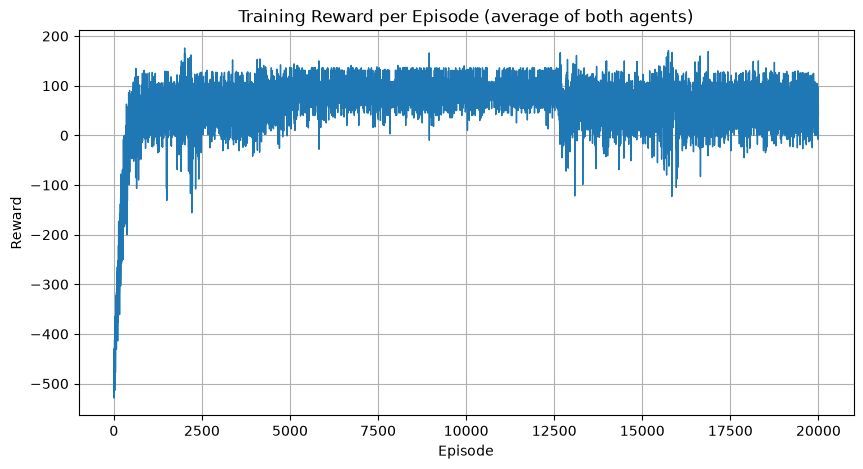

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, linewidth=1)
plt.title("Training Reward per Episode (average of both agents)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

## Final Summary
The trained agents should now demonstrate the desired emergent behavior:

Type A avoids the lake when flooded (to prevent water damage).

Type B willingly crosses the flooded lake (it is waterproof).

Collisions inside the lake are minimized because Type A and Type B cross at different lake states.



In [29]:
print("=" * 60)
print("📊 FINAL PERFORMANCE STATISTICS")
print("=" * 60)
print(f"Total collisions (training): {collision_count}")
print(f"Water damage events (training): {water_damage_count}")
print(f"Agent A deliveries: {delivery_count_A}")
print(f"Agent B deliveries: {delivery_count_B}")
print("=" * 60)

📊 FINAL PERFORMANCE STATISTICS
Total collisions (training): 30580
Water damage events (training): 2152
Agent A deliveries: 159449
Agent B deliveries: 222449
